In [1]:

# Step 0 — Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Optional joblib for loading scaler if you saved it during training
try:
    import joblib
except Exception:
    joblib = None
    
    

In [2]:
# Load the simulated CSV

for fname in ("Simulated_Rain_Data.csv", "Rainfall.csv", "rainfall_simulation.csv", "Rainfall_Simulation_Predictions.csv"):
    if os.path.exists(fname):
        csv_file = fname
        break
else:
    raise FileNotFoundError("Could not find simulation CSV. Please place 'Rainfall_Simulation.csv' in the working folder.")

data = pd.read_csv(csv_file)
print("Loaded:", csv_file)
print("Original columns:", data.columns.tolist())


Loaded: Simulated_Rain_Data.csv
Original columns: ['day', 'pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed', 'rain_intensity', 'rain_sensor']


In [3]:
# clean column names (strip spaces, lowercase, replace spaces with underscores)
def clean_name(c):
    c2 = str(c).strip().lower()
    c2 = c2.replace(" ", "_")
    # fix common typo in some datasets
    c2 = c2.replace("temparature", "temperature")
    # unify names
    c2 = c2.replace("rainsensor", "rain_sensor")
    c2 = c2.replace("rainintensity", "rain_intensity")
    return c2

data.columns = [clean_name(c) for c in data.columns]
print("Cleaned columns:", data.columns.tolist())


Cleaned columns: ['day', 'pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed', 'rain_intensity', 'rain_sensor']


In [4]:
# Ensure important columns exist & convert types

if 'rainfall' in data.columns and data['rainfall'].dtype == object:
    data['rainfall'] = data['rainfall'].str.strip().str.lower().map({'yes':1,'no':0})
    data['rainfall'] = pd.to_numeric(data['rainfall'], errors='coerce').fillna(0).astype(int)

# If rain_intensity or rain_sensor name variants exist, normalize them:
if 'rainintensity' in data.columns and 'rain_intensity' not in data.columns:
    data['rain_intensity'] = data.pop('rainintensity')
if 'rainsensor' in data.columns and 'rain_sensor' not in data.columns:
    data['rain_sensor'] = data.pop('rainsensor')

print("Post-type columns and dtypes:")
print(data.dtypes)

Post-type columns and dtypes:
day                 int64
pressure          float64
maxtemp           float64
temperature       float64
mintemp           float64
dewpoint          float64
humidity            int64
cloud               int64
rainfall            int64
sunshine          float64
winddirection     float64
windspeed         float64
rain_intensity      int64
rain_sensor         int64
dtype: object


In [5]:
# Select feature columns automatically

possible_targets = ['rain_intensity', 'rainintensity', 'rain_int', 'rain_int']
target_col = next((c for c in possible_targets if c in data.columns), None)
print("Detected target column:", target_col)

# numeric columns
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
# remove day if present
for rem in ['day','index']:
    if rem in numeric_cols:
        numeric_cols.remove(rem)
# remove target if present
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# remove predicted columns if present
if 'predicted_rain' in numeric_cols:
    numeric_cols.remove('predicted_rain')


if 'rain_sensor' in numeric_cols:
    numeric_cols = [c for c in numeric_cols if c!='rain_sensor'] + ['rain_sensor']

features = numeric_cols
print("Auto-selected feature columns (in this order):", features)

if len(features) == 0:
    raise ValueError("No numeric feature columns found. Check your CSV and column cleaning step.")

# Prepare X matrix (raw)
X_raw = data[features].copy()
# ensure floats
X_raw = X_raw.astype(float)



Detected target column: rain_intensity
Auto-selected feature columns (in this order): ['pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed', 'rain_sensor']


In [7]:
# Load or fit scaler

scaler_path = "scaler.pkl"
scaler = None
if joblib is not None and os.path.exists(scaler_path):
    try:
        scaler = joblib.load(scaler_path)
        print("Loaded scaler from", scaler_path)
    except Exception as e:
        print("Failed to load scaler.pkl:", e)
        scaler = None

if scaler is None:
    print("No scaler.pkl found — fitting a new StandardScaler on simulation data.")
    scaler = StandardScaler()
    scaler.fit(X_raw)

# scale features
X_scaled = scaler.transform(X_raw)
joblib.dump(scaler, "scaler_used_for_simulation.pkl")
print("Saved scaler to scaler_used_for_simulation.pkl")


No scaler.pkl found — fitting a new StandardScaler on simulation data.
Saved scaler to scaler_used_for_simulation.pkl


In [8]:
# Load the TFLite model and allocator

tflite_path = "rain_nn_model.tflite"
if not os.path.exists(tflite_path):
    raise FileNotFoundError(f"{tflite_path} not found. Put your TFLite file in the notebook folder.")

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("TFLite input:", input_details)
print("TFLite output:", output_details)

expected_dim = input_details[0]['shape'][-1]
if expected_dim != X_scaled.shape[1]:
    print(f"Warning: TFLite model expects {expected_dim} features but we have {X_scaled.shape[1]}.")
    print("Proceeding anyway but results may be incorrect. If mismatch, retrain model with same feature order/cols.")


TFLite input: [{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([ 1, 12], dtype=int32), 'shape_signature': array([-1, 12], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
TFLite output: [{'name': 'StatefulPartitionedCall_1:0', 'index': 10, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


c:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [10]:
# Run inference (row-by-row) and create prediction columns

preds = []
probs = []

for i in range(X_scaled.shape[0]):
    inp = X_scaled[i].reshape(1, -1).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], inp)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]['index'])
    pred_class = int(np.argmax(out, axis=1)[0])
    preds.append(pred_class)
    probs.append(out.flatten().tolist())

data['predicted_rain'] = preds
data['predicted_probabilities'] = probs  # list per row (optional)

# Map numeric class to readable labels
label_map = {0:"No Rain", 1:"Light Rain", 2:"Heavy Rain"}
data['predicted_label'] = data['predicted_rain'].map(label_map)

print("Sample predictions:")
display(data[[*features[:3], 'rain_sensor']].head())  # show a few features + sensor
display(data[['predicted_rain','predicted_label']].head())

Sample predictions:


,pressure,maxtemp,temperature,rain_sensor
0,1025.9,19.9,18.3,361
1,1022.0,21.7,18.9,967
2,1019.7,20.3,19.3,784
3,1018.9,22.3,20.6,815
4,1015.9,21.3,20.7,863


,predicted_rain,predicted_label
0,1,Light Rain
1,2,Heavy Rain
2,2,Heavy Rain
3,2,Heavy Rain
4,2,Heavy Rain


In [11]:
# Save predictions

out_name = "Rainfall_Simulation_Predictions.csv"
data.to_csv(out_name, index=False)
print("Saved predictions to", out_name)

Saved predictions to Rainfall_Simulation_Predictions.csv


Accuracy: 0.9972677595628415
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       117
           1       0.99      1.00      0.99        90
           2       1.00      0.99      1.00       159

    accuracy                           1.00       366
   macro avg       1.00      1.00      1.00       366
weighted avg       1.00      1.00      1.00       366



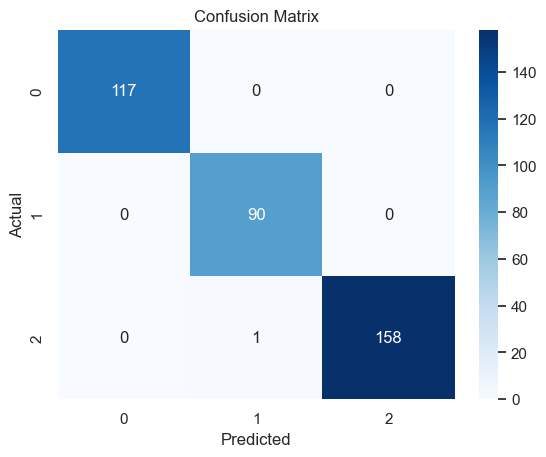

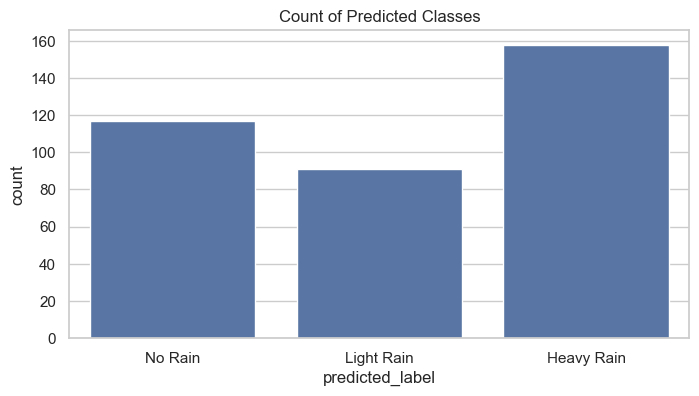

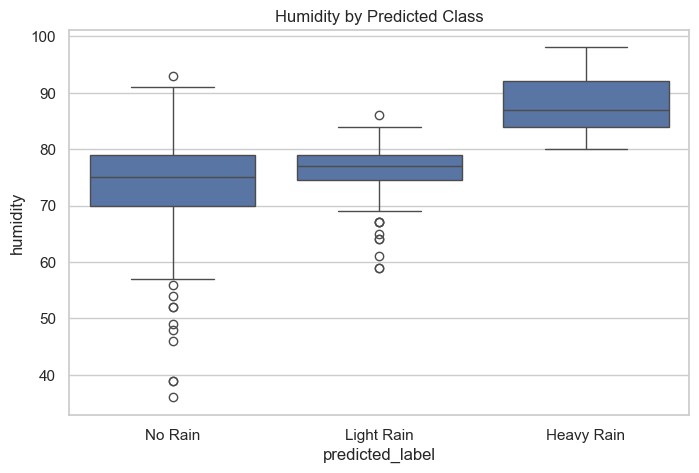

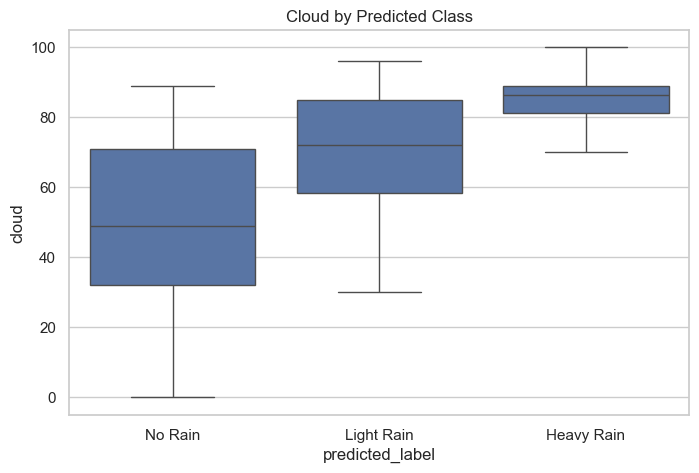

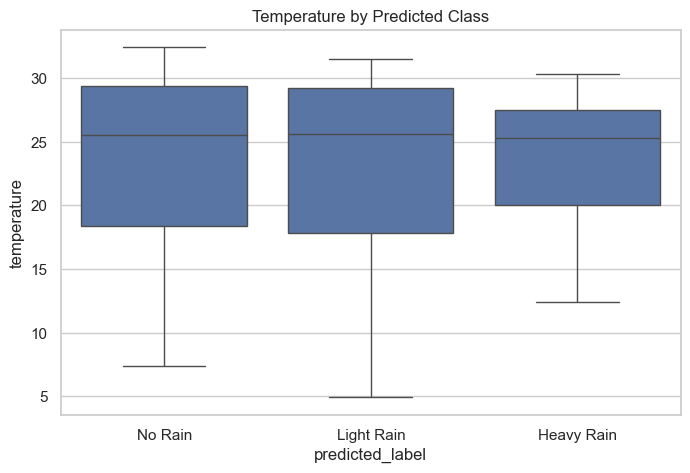

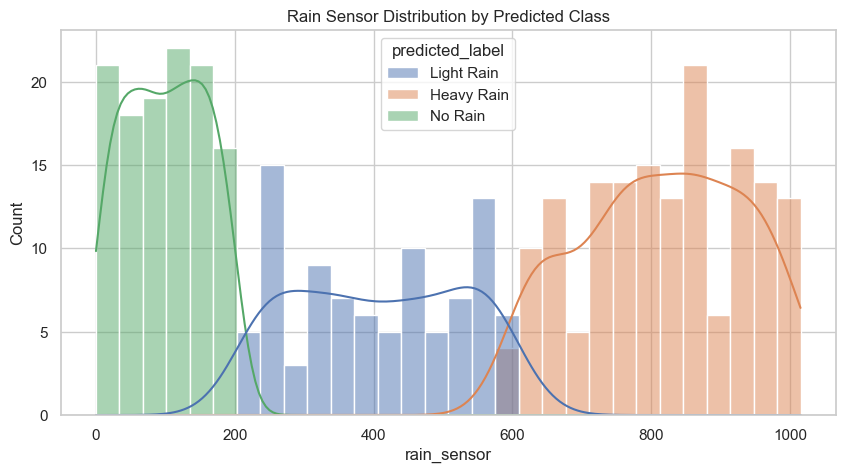

In [12]:
# Diagnostics & Plots

plt.rcParams.update({'figure.max_open_warning': 0})
sns.set(style="whitegrid")


if target_col is not None and target_col in data.columns:
    y_true = data[target_col].astype(int)
    y_pred = data['predicted_rain'].astype(int)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification report:")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
else:
    print("No actual target found in data — skipping confusion matrix.")


# Distribution of predicted classes
plt.figure(figsize=(8,4))
sns.countplot(x='predicted_label', data=data, order=["No Rain","Light Rain","Heavy Rain"])
plt.title("Count of Predicted Classes")
plt.show()


# Boxplots of humidity and cloud grouped by predicted class
for col in ['humidity','cloud','temperature']:
    if col in data.columns:
        plt.figure(figsize=(8,5))
        sns.boxplot(x='predicted_label', y=col, data=data, order=["No Rain","Light Rain","Heavy Rain"])
        plt.title(f"{col.capitalize()} by Predicted Class")
        plt.show()


# Rain sensor histogram by predicted class
if 'rain_sensor' in data.columns:
    plt.figure(figsize=(10,5))
    sns.histplot(data, x='rain_sensor', hue='predicted_label', bins=30, kde=True)
    plt.title("Rain Sensor Distribution by Predicted Class")
    plt.show()


In [ ]:
# Quick sample inference from a single sensor value


def predict_from_sensor(sensor_value, sample_row_index=0):
    # build a row from sample structure (use sample_row_index for other feature defaults)
    row = X_raw.iloc[sample_row_index].copy()
    # set the sensor value
    if 'rain_sensor' in row.index:
        row['rain_sensor'] = sensor_value
    else:
        print("No 'rain_sensor' column in features.")
    # scale the row
    inp = scaler.transform([row.values.astype(float)]).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], inp)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]['index'])
    pred = int(np.argmax(out, axis=1)[0])
    return pred, out.flatten().tolist()


for s in [50, 350, 850]:
    p, probs = predict_from_sensor(s, sample_row_index=0)
    print(f"Sensor={s} => Predicted {p} ({label_map[p]})  probs={probs}")


Sensor=50 => Predicted 1 (Light Rain)  probs=[0.00849343091249466, 0.991496205329895, 1.0436179763928521e-05]
Sensor=350 => Predicted 1 (Light Rain)  probs=[0.002118585165590048, 0.9977813363075256, 0.00010013520659413189]
Sensor=850 => Predicted 1 (Light Rain)  probs=[0.00037169360439293087, 0.9937171936035156, 0.005911065265536308]


c:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Visualization - Plot sensor values vs predicted classes.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import joblib
import os

In [17]:
# Load TFLite model

interpreter = tf.lite.Interpreter(model_path="rain_nn_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [18]:
# Load or fit scaler

scaler_path = "scaler_used_for_simulation.pkl"

if os.path.exists(scaler_path):
    scaler = joblib.load(scaler_path)
    print("Loaded scaler from", scaler_path)
else:
    print("No scaler file found, fitting a new StandardScaler on dummy data.")
    # Dummy features: (sensor, humidity, cloud, temperature, dewpoint)
    X_dummy = np.array([[0, 70, 50, 25, 10],
                        [1023, 90, 80, 30, 20]])
    scaler = StandardScaler()
    scaler.fit(X_dummy)
    joblib.dump(scaler, scaler_path)
    print("New scaler fitted and saved to", scaler_path)

Loaded scaler from scaler_used_for_simulation.pkl


In [30]:
# Function for prediction

def predict_rain(sensor_value):
    # Fill dummy values for weather features
    # Order must match training: ['pressure','maxtemp','temperature','mintemp','dewpoint','humidity','cloud','rainfall','sunshine','winddirection','windspeed','RainSensor']
    features = np.array([[ 
        1013,   # pressure
        35,     # maxtemp
        30,     # temperature
        25,     # mintemp
        20,     # dewpoint
        70,     # humidity
        80,     # cloud
        1,      # rainfall
        8,      # sunshine
        180,    # winddirection
        15,     # windspeed
        sensor_value  # RainSensor (simulated sensor)
    ]])

    
    # Scale features
    features_scaled = scaler.transform(features)

    # TFLite prediction
    interpreter.set_tensor(input_details[0]['index'], features_scaled.astype(np.float32))
    interpreter.invoke()
    
    probs = interpreter.get_tensor(output_details[0]['index'])[0]
    pred_class = np.argmax(probs)
    
    return pred_class, probs


In [31]:
# Simulated sensor values

sensor_values = np.linspace(0, 1023, 20, dtype=int)
results = []

for val in sensor_values:
    pred_class, probs = predict_rain(val)
    results.append([val, pred_class, probs.tolist()])
results_df = pd.DataFrame(results, columns=['sensor_value', 'predicted_class', 'predicted_probabilities'])
print(results_df)

    sensor_value  predicted_class  \
0              0                1   
1             53                1   
2            107                1   
3            161                1   
4            215                1   
5            269                1   
6            323                1   
7            376                1   
8            430                1   
9            484                1   
10           538                1   
11           592                1   
12           646                1   
13           699                1   
14           753                1   
15           807                2   
16           861                2   
17           915                2   
18           969                2   
19          1023                2   

                              predicted_probabilities  
0   [0.00016927570686675608, 0.9998303651809692, 3...  
1   [0.0001989269512705505, 0.9998003840446472, 7....  
2   [0.00023286470968741924, 0.9997656941413879, 1... 

c:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with featur

In [32]:
# Convert to DataFrame

df = pd.DataFrame(results, columns=["Sensor Value", "Predicted Class", "Probabilities"])


Save to CSV

In [33]:
df.to_csv("rain_predictions.csv", index=False)
print(" Predictions saved to rain_predictions.csv")

 Predictions saved to rain_predictions.csv


Visualization

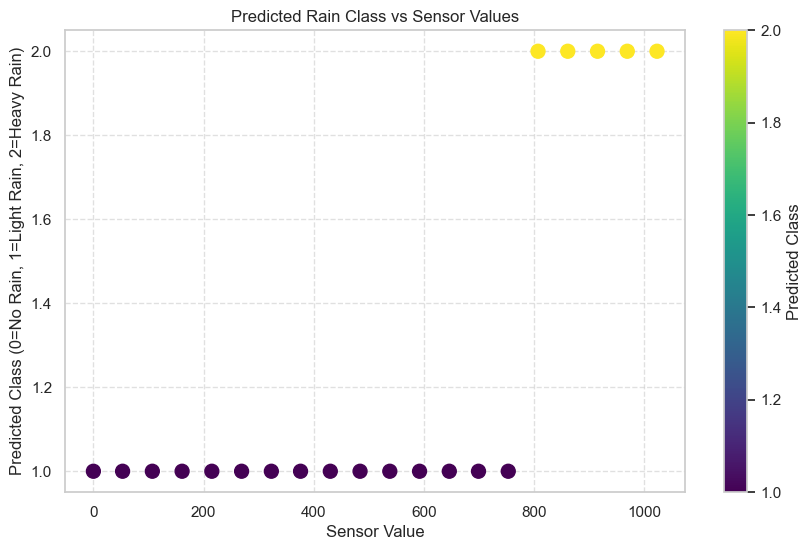

In [34]:
plt.figure(figsize=(10,6))
plt.scatter(df["Sensor Value"], df["Predicted Class"], c=df["Predicted Class"], cmap="viridis", s=100)
plt.title("Predicted Rain Class vs Sensor Values")
plt.xlabel("Sensor Value")
plt.ylabel("Predicted Class (0=No Rain, 1=Light Rain, 2=Heavy Rain)")
plt.colorbar(label="Predicted Class")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()